# Preprocessing examples

This lab document covers a series of 'additional' topics in machine learning, mainly focused on preprocessing techniques. Although we will spend most of this semester looking at different algorithms, you will find that data manipulation makes up a significant part of any project, so some of these methods will likely be of use in your projects. 

We'll cover the following subjects:

- Feature transformation
- Encoding categorical features
- Missing data imputation
- Feature selection
- Working with imbalanced data
- Pipelines

There is no assignment for this lab - but I'd suggest at least looking over the approaches to get a sense of when these may be useful. Let's load some general libraries to get started.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## Feature transformation

The goal of these methods is to transform individual features in some way, principally with the aim of reducing any bias in model training that results from data distributions or magnitudes.

### Simple transformation

For many methods, having continuous features that are approximately normally distributed can be important. Highly skewed data can present issues in estimating the extremes. The following are a set of simple transformation methods for both right- and left-skewed data

#### Right-skewed data

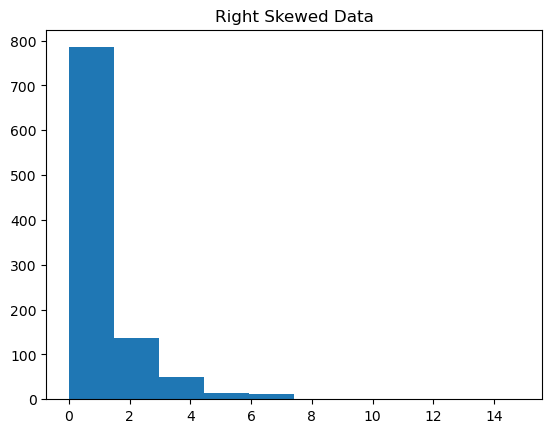

In [2]:
## Make some right skewed data
right_skew = np.random.normal(0, 1, size = 1000)**2

plt.hist(right_skew)
plt.title("Right Skewed Data")
plt.show()

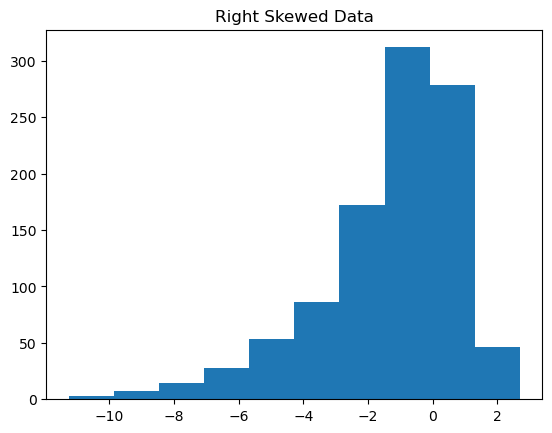

In [3]:
## Log transformation
right_skew_log = np.log(right_skew)

plt.hist(right_skew_log)
plt.title("Right Skewed Data")
plt.show()

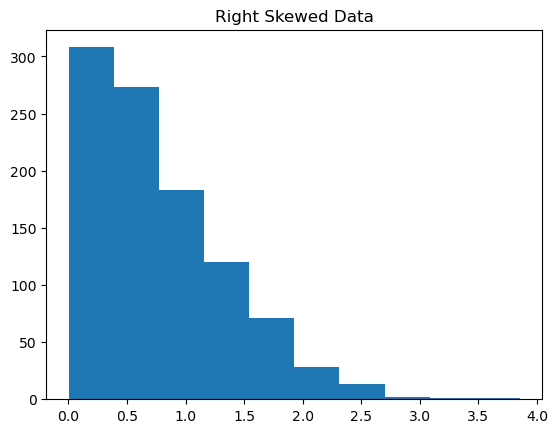

In [4]:
## Sqrt transformation
right_skew_sqrt = np.sqrt(right_skew)

plt.hist(right_skew_sqrt)
plt.title("Right Skewed Data")
plt.show()

##### Left-skewed data

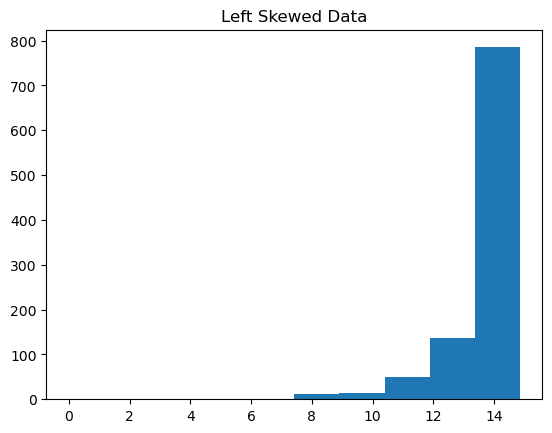

In [5]:
# Reflect the data around a constant (e.g., the maximum value) to make it left-skewed
left_skew = np.max(right_skew) - right_skew

plt.hist(left_skew)
plt.title("Left Skewed Data")
plt.show()

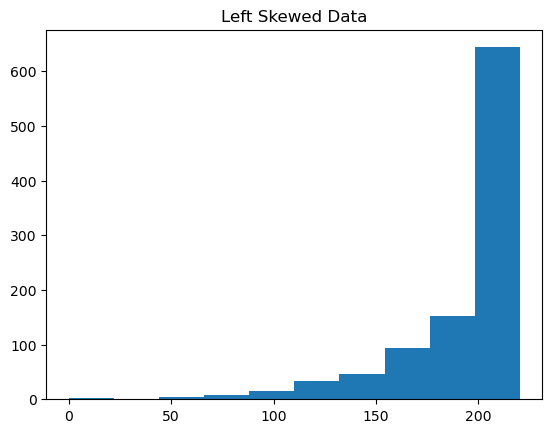

In [6]:
## Squared transformation
left_skew_sq = left_skew**2

plt.hist(left_skew_sq)
plt.title("Left Skewed Data")
plt.show()

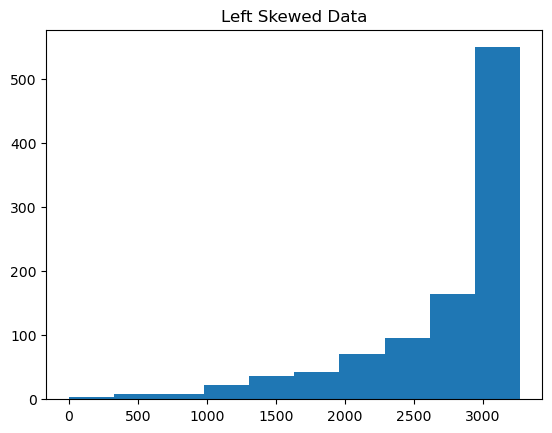

In [7]:
## Cube transformation
left_skew_cube = left_skew**3

plt.hist(left_skew_cube)
plt.title("Left Skewed Data")
plt.show()

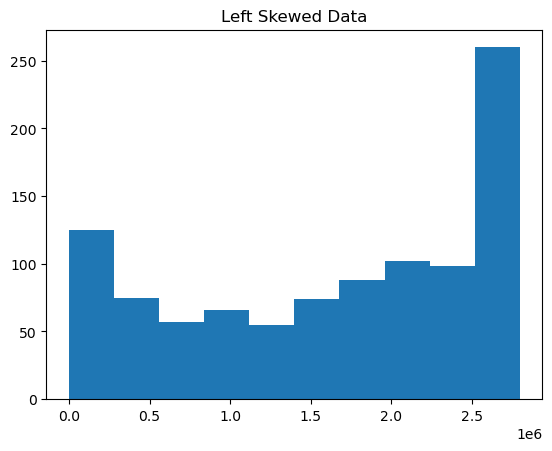

In [8]:
## Exponential transformation
left_skew_exp = np.exp(left_skew)

plt.hist(left_skew_exp)
plt.title("Left Skewed Data")
plt.show()

### Standardization and normalization

For some algorithms, having very different ranges for features (e.g. one feature in 0-1 and another in 0-1000000), can results in biases, where more attention is paid to the larger magnitude feature. These two approaches are ways to transform variables by rescaling them, with the goal of ensuring that all features have the same (or approximately) the same range. 

Start by making up some random data with a fairly large magnitude:

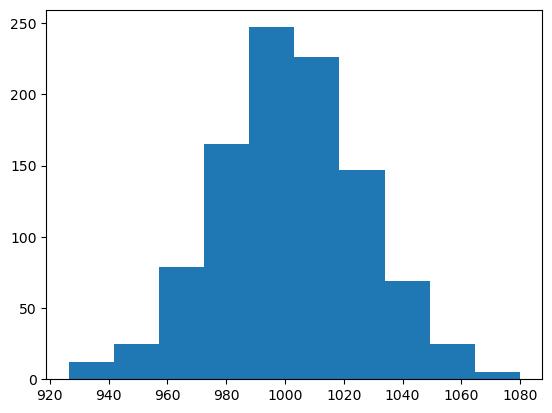

In [9]:
X = np.random.normal(loc = 1000, scale = 25, size = 1000).reshape(-1, 1)
plt.hist(X)
plt.show()

#### Standardization

Standardizing features converts them into $z$-scores by subtracting the mean and dividing by the standard deviation:
$$
z_i = (x_i - \bar{x}) / \sigma_x
$$

This has some attractive properties: it rescales all features to the same range; a value of 0 is equal to the mean; and values of -1 and 1 equal 1 s.d. below or above the mean, respectively, for all features. 

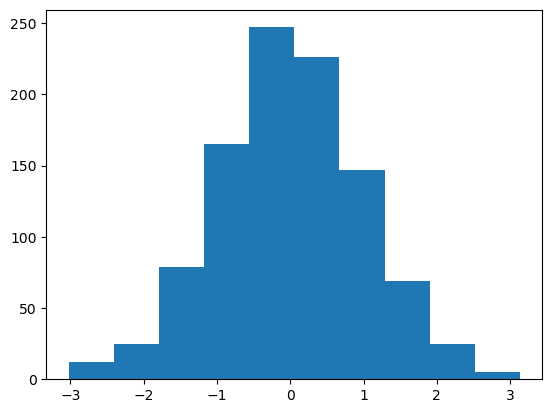

In [10]:
## Standardize (z-score)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

plt.hist(X_std)
plt.show()

#### Normalization

Normalization rescales features to a fixed range, usually $[0-1]$ (also called a min-max transformation). This is frequently used with neural networks to help in training models. 

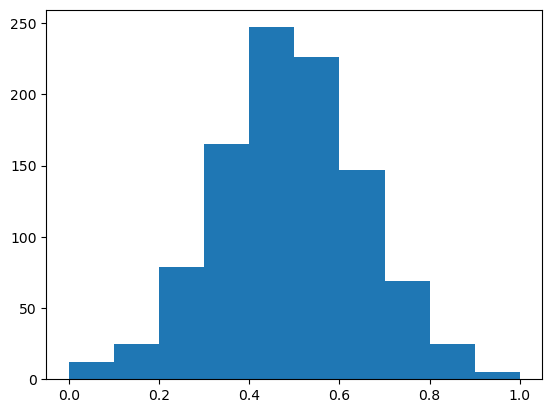

In [11]:
## Normalize (min-max)
from sklearn.preprocessing import MinMaxScaler

X_norm = MinMaxScaler().fit_transform(X) ## All in one...

plt.hist(X_norm)
plt.show()

## Imputation

Many datasets contain missing values, usually defined by a computer as `NA` or `NaN` for 'not-a-number'. For many machine learning algorithm, these pose problems, and the functions will often fail. If your dataset contains missing values, you can either drop them (see **pandas** `drop_na` function, for example), or to *impute* them. This refers to replacing the missing values with a guess. We'll look at some different approaches to do that here. We'll demonstrate these here on a simulated dataset in the file *employees_dataset_with_missing2.csv* taken from Jason Brownlee's blog on machine learning.

Let's start by loading the data and quickly checking to see how many `NaN`s there are in each feature

In [12]:
df = pd.read_csv("./datafiles/employees_dataset_with_missing2.csv")
df.head()

,age,income,education_years,experience,credit_score
0,NaN,70990.331549,11.974465,0.460962,563.650640
1,33.617357,63869.505244,13.566444,5.698075,646.879651
2,41.476885,50894.455549,11.622740,7.931972,651.801687
3,50.230299,40295.948334,13.076115,NaN,697.263035
4,32.658466,60473.349704,8.319156,12.782766,513.314164


In [13]:
# Identify missing values
print('Check Null values \n',np.sum(np.isnan(df)))

Check Null values 
 age                116
income             149
education_years     91
experience         128
credit_score         0
dtype: int64


/opt/homebrew/Caskroom/miniforge/base/envs/geog5160/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Next we'll split these into features (`X`) and the targets (`y`):

In [14]:
all_vars = ['age', 'income', 'education_years', 'experience']
            
X = df[all_vars]
y = df['credit_score']

If you now try and fit a simple model, you'll see that this fails due to the presence of `NaN`s (this is commented out at present to allow the notebook to run)

In [15]:
## Try fitting a simple model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
## regressor.fit(X, Y) ## Doesn't work due to NAs

We'll now try to impute these. Just as a reminder, here are the top few rows in the dataset, so that you can compare the results from imputation (note the missing values for age and experience)

In [16]:
X.head()

,age,income,education_years,experience
0,NaN,70990.331549,11.974465,0.460962
1,33.617357,63869.505244,13.566444,5.698075
2,41.476885,50894.455549,11.622740,7.931972
3,50.230299,40295.948334,13.076115,NaN
4,32.658466,60473.349704,8.319156,12.782766


### Simple imputation

We'll start with simple imputation. This replaces the missing values with a constant value, usually the mean or median. For categorical variables, we can replace with the mode or most frequent category. We'll use mean imputation, so first let's see what the mean values is for age and experience:

In [17]:
print(f'Mean age       : {np.mean(df['age']):.3f}')
print(f'Mean experience: {np.mean(df['experience']):.3f}')

Mean age       : 35.280
Mean experience: 9.999


Now we'll impute. Note that this follows a similar pattern to most scikit-learn functions. We import the function, instantiate it, then fit it. We use a slightly different method here (`fit_transform`) that both learns the value to impute (the `fit` bit), then uses this to make the imputation (the `transform` bit). Compare the results to the original data above:

In [18]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)
X_imputed.head()

,age,income,education_years,experience
0,35.279903,70990.331549,11.974465,0.460962
1,33.617357,63869.505244,13.566444,5.698075
2,41.476885,50894.455549,11.622740,7.931972
3,50.230299,40295.948334,13.076115,9.999094
4,32.658466,60473.349704,8.319156,12.782766


Now if we try to train a model using the imputed data, it will run successfully.

In [19]:
regressor.fit(X_imputed, y) ## Now it works!

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
print('\nCoefficient :',regressor.coef_)
print('Intercept :',regressor.intercept_)


Coefficient : [-3.06576521e-01 -3.66087646e-04  1.30831224e+00  3.59588819e-01]
Intercept : 652.6349815405331


### KNN imputer

An alternative to try to make a more educated guess as to the imputed value. The KNN imputer uses a nearest neighbor approach. For a feature $x$ with a missing value for observation $i$, tt searches for the closet neighboring points using all the features that are non `NaN`s. It then imputes the missing value for $x$, usually as the mean of the set of neighbors. This can be distance weighted, so that closer neighboring point have a greater influence on the result. Note that you have to set the choice of $k$, the number of neighbors that are used.

In [21]:
from sklearn.impute import KNNImputer

## Create KNNImputer object with 2 neighbors
knn_imputer = KNNImputer(n_neighbors=2)

## Fit and transform the data
X_knn_imputed = knn_imputer.fit_transform(X)
X_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

X_knn_imputed.head()

,age,income,education_years,experience
0,29.052459,70990.331549,11.974465,0.460962
1,33.617357,63869.505244,13.566444,5.698075
2,41.476885,50894.455549,11.622740,7.931972
3,50.230299,40295.948334,13.076115,16.909106
4,32.658466,60473.349704,8.319156,12.782766


### Iterative imputer

The final method that we'll look at uses a sequence of models to impute missing data. It starts by using a simple imputation method to fill missing values (default = mean). It then iterates over each feature with missing values, creating a model of that feature as a function of all the remaining features. This is used to impute a value for each of the original missing values. It then moves on to the next feature and does the same. Once it has been through all the features, it repeats the entire process until there is only a marginal change in the imputed values, or a limit of iterations is reached. 

This has a large amount of flexibility: you can choose the model that is used for imputation, and, as we'll see later, it allows multiple imputation

In [22]:
from sklearn.experimental import enable_iterative_imputer ## Note this is still currently in experimental
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor ## Algorithm for imputation

In [23]:
rf_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42),
    random_state=42,
    max_iter=5 ## Number of updates
)

In [24]:
X_rf_imputed = pd.DataFrame(
    rf_imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

X_rf_imputed.head()

/opt/homebrew/Caskroom/miniforge/base/envs/geog5160/lib/python3.12/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,age,income,education_years,experience
0,36.583605,70990.331549,11.974465,0.460962
1,33.617357,63869.505244,13.566444,5.698075
2,41.476885,50894.455549,11.622740,7.931972
3,50.230299,40295.948334,13.076115,13.333607
4,32.658466,60473.349704,8.319156,12.782766


If we replace the random forest with the default algorithm (`BayesianRidge`), we can now run mulitple imputations, allowing a test of how much the model changes with different imputed values, simply by changing the `random_state` argument to a different value:

In [25]:
from sklearn.linear_model import BayesianRidge

rf_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    random_state=42,
    max_iter=5,
    sample_posterior=True
)

X_rf_imputed = pd.DataFrame(
    rf_imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

X_rf_imputed.head()

,age,income,education_years,experience
0,55.715286,70990.331549,11.974465,0.460962
1,33.617357,63869.505244,13.566444,5.698075
2,41.476885,50894.455549,11.622740,7.931972
3,50.230299,40295.948334,13.076115,7.693746
4,32.658466,60473.349704,8.319156,12.782766


And repeat...

In [26]:
br_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    random_state=4321,
    max_iter=5,
    sample_posterior=True
)

X_br_imputed = pd.DataFrame(
    br_imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

X_rf_imputed.head()

,age,income,education_years,experience
0,55.715286,70990.331549,11.974465,0.460962
1,33.617357,63869.505244,13.566444,5.698075
2,41.476885,50894.455549,11.622740,7.931972
3,50.230299,40295.948334,13.076115,7.693746
4,32.658466,60473.349704,8.319156,12.782766


## PCA transformation

Another useful transformation of data is through a principal component transformation. This is a commonly used form of dimension reduction, that can often reduce datasets with large numbers of features down to a small number of principal components. In addition, as PCA is based on the co-variation between features, it can avoid issues of multicollinearity or redundancy with features that record similar real world factors. We'll look at this here with a breast cancer dataset, which has a relatively large number of features (30). 

In [27]:
df = pd.read_csv('datafiles/breast_cancer_data.csv') ## Load data
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True) ## Remove extra column
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [28]:
## Transform target into a binary value
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [29]:
## Split into features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

We'll next use the `StandardScaler` to transform everything to a $z$-score (note this is an important step for PCA)

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Next, split the data into training and testing (se we can see the effect of using PCA in a model):

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

And we'll build a simple initial model using logistic regression and all original, scaled features (30). We'll use the test set to evaluate and the `classification_report` function to see how well the model worked:

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



The model looks good, with all metrics recorded over 0.95. Now, we'll rebuild the model using a PCA transformation of the features. As usual, we'll load the `PCA` function, instantiate it, then fit to the data. Rather than using `fit_transform`, we will do the two steps separately. This allows us to define the PCA using the training set, then use this to 'transform' both the training and test set, reducing any data 'leakage' between the two. 

We also specify how many compnents to return (this is the number of features summarizing the original dataset that we will use in our model). The output is simply an array with one component per column, and a score on that component for each observations, and this can then be used directly in fitting models.

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_train)

X_train_pca = pca.transform(X_train)
print(X_train_pca)

[[ 4.54908308e+00  9.41717321e+00]
 [ 8.98390371e+00  3.48443829e-01]
 [-2.18387278e+00  3.34216949e+00]
 [-2.53992691e+00  7.17342176e-01]
 [-2.25789278e+00  2.63255649e+00]
 [ 4.11060110e+00  2.83744068e+00]
 [ 3.25931564e+00  4.53528423e+00]
 [-3.24375729e+00 -3.77193585e-01]
 [-2.39570069e+00  3.23831742e-02]
 [ 3.33787340e+00 -2.40868713e+00]
 [-8.97085142e-01  9.71480118e-01]
 [ 4.27020833e+00 -4.08835623e+00]
 [ 3.14448278e+00  1.38409522e+00]
 [-2.61236008e+00  1.47737138e+00]
 [-3.15626177e+00 -1.42692982e+00]
 [ 4.94935215e+00 -1.24963477e+00]
 [ 9.25865794e+00  1.62305924e+00]
 [ 5.93445485e+00  3.42829497e+00]
 [-2.82906040e+00 -2.41935929e+00]
 [-3.31053210e+00 -5.24444943e-02]
 [-2.10256540e+00 -2.41916679e+00]
 [ 4.81497073e+00  3.14530988e+00]
 [-4.86026086e-01  1.11761752e-01]
 [-2.17014740e+00  2.04250503e+00]
 [ 1.30782725e+00  9.62061575e-01]
 [ 1.25525108e+00  2.53907129e-01]
 [-2.89655918e+00  3.63107445e-01]
 [ 4.89976908e+00 -4.19595024e+00]
 [-3.60573236e+00  7

How do you know how many components to use? PCA can return as many summary features as original features, but of rapidly diminishing utility. A simple way to check is to see how much variance is explained by the set of components you have chose. This information is stored in `pca.explained_variance_ratio_`). Here, the first two components explain about 63% of the original variance. 

In [34]:
print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

Explained variance: [0.4325482  0.19732988]
Cumulative: [0.4325482  0.62987809]


Now transform the test set, then fit a model using only the PCA-transformed features (and evaluate with the PCA-transformed test set):

In [35]:
X_test_pca = pca.transform(X_test)

In [36]:
logreg = LogisticRegression()
logreg.fit(X_train_pca, y_train)

y_pred = logreg.predict(X_test_pca)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        71
           1       1.00      0.98      0.99        43

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



Despite having reduced the dataset from 30 features to 2, we see a slight improvement in the resulting model. This is because PCA tries to identify importance variation in the features, and remove noise. Just to chcek, we can print the number of coefficients: here there are only 2, as we only used 2 PCA components

In [37]:
print('\nCoefficient :',logreg.coef_)
print('Intercept :',logreg.intercept_)


Coefficient : [[ 1.89080372 -1.08847514]]
Intercept : [-0.45574444]


## Feature selection

An alternative approach with a large number of features is to use a feature selection method. These range from simple statistical testss to more complex model-based methods. We'll look here at a couple of examples using the breast cancer data set loaded earlier. As a reminder, the original data has 30 features:

In [38]:
X.shape

(569, 30)

In [39]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Univariate feature selection

This approach does pairwise comparisons of each feature with the target. For each a simple statistical test is performed, and then a filter is applied. The test are based on the correlation between variables, and options include:

- Classification: 
    - `f_classif`: tests correlation using Pearsons correlation
    - `chi2` uses Chi^2 test of association
    - `mutual_info_classif`: mutual information
- Regression: 
    - `f_regression`: tests correlation using Pearsons correlation
    - `r_regression`: tests correlation using a linear model and R2
    - `mutual_info_classif`: mutual information

All methods except mutual information assume that the feature and `y` are linearly related. Mutual information is more flexible but generally requires larger number of observations.

Once the tests have been run, the results are then passed to a selection function that returns only the most correlated or informative features. There are a couple of options:

- `SelectKBest`: select the top $k$ features
- `SelectPercentile`: select the $p$% of the set of features

We'll demonstrate this here using `f_classif` (as this is a classification task) and `SelectKBest` to get the top 4 features. We'll first make a selector by using the `fit` method:

### Univariate feature selection

This approach does pairwise comparisons of each feature with the target. For each a simple statistical test is performed, and then a filter is applied. The test are based on the correlation between variables, and options include:

- Classification: 
    - `f_classif`: tests correlation using Pearsons correlation
    - `chi2` uses Chi^2 test of association
    - `mutual_info_classif`: mutual information
- Regression: 
    - `f_regression`: tests correlation using Pearsons correlation
    - `r_regression`: tests correlation using a linear model and R2
    - `mutual_info_classif`: mutual information

All methods except mutual information assume that the feature and `y` are linearly related. Mutual information is more flexible but generally requires larger number of observations.

Once the tests have been run, the results are then passed to a selection function that returns only the most correlated or informative features. There are a couple of options:

- `SelectKBest`: select the top $k$ features
- `SelectPercentile`: select the $p$% of the set of features

We'll demonstrate this here using `f_classif` (as this is a classification task) and `SelectKBest` to get the top 4 features. We'll first make a selector by using the `fit` method:

In [40]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

select_k = SelectKBest(f_classif, k=4).fit(X, y)

Now use the selector to transform the original `X` to select the features:

In [41]:
X_new = select_k.transform(X)
X_new.shape

(569, 4)

As this returns an array, we lose information about which features were selected. As the selector stores the columns indices, we can use these with the original data to print the selected features:

In [42]:
# Get columns to keep and create new dataframe with those only
cols_idxs = select_k.get_support(indices=True)
X.columns[cols_idxs]

Index(['concave points_mean', 'radius_worst', 'perimeter_worst',
       'concave points_worst'],
      dtype='object')

### Recursive feature elimination (RFE)

The previous approaches require you to define the number (or percent) of features to retain. An alternative approach uses recursive feature elimination. This starts with a model that relates all features to the target. The importance of each feature is then obtained from the model (usually the model importance or coefficients), and the least important feature is eliminated. The whole process is then repeated. Standard RFE still requires you to define the number of features desired, but this can also be run in a cross-validation loop to select the optimal number. We'll do that here using a simple logistic regression to calculate importance scores. The optimal number is chosen by the set that gives the best prediction results with the test dataset during the cross-validation.

In [43]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

min_features_to_select = 2  # Minimum number of features to consider
rf = RandomForestClassifier()
cv = StratifiedKFold(5)

rfecv = RFECV(
    estimator=rf,
    step=1,
    cv=cv,
    scoring="accuracy",
    min_features_to_select=min_features_to_select,
    n_jobs=2,
)
rfecv.fit(X, y)

print(f"Optimal number of features: {rfecv.n_features_}")

Optimal number of features: 10


## Imbalanced data

Next, we'll look at ways to work with imbalanced data. This generally refers to classification datasets, where the target variable has substantially more of one class than the other(s). This is very common in real world dataset, particularly anything dealing with a rare outcome. Imbalanced data can cause issues in:

- Model training: loss function is dominated by majority class
- Model evaluation: performance for minority class is under-represented

There are a range of different approaches for dealing with this, but these largely can be split into weighting methods and sampling methods. Let's set up a couple of function to report some simple classification statistics, as well as the imbalance ratio (the ratio of the minority to majority class)

In [44]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

def get_accuracy(y, y_pred):
    acc = accuracy_score(y_test, y_test_pred)
    bacc = balanced_accuracy_score(y_test, y_test_pred)
    print(f'Accuracy: {acc:.4f}')
    print(f'Balanced accuracy: {bacc:.4f}')

def imbalance_ratio(y):
    print("Class Distribution:")
    print(y.value_counts())

    # Imbalance ratio (%)
    imbalance_ratio = y.value_counts().min() / y.value_counts().max()
    print(f"Imbalance ratio: {imbalance_ratio:.3f}")

Next we'll load some imbalanced data (this is a data set of credit applications, with the final column indicating whether an application was rejected (`yes`) or not). We'll do some cleaning, scaling and one-hot encoding, then split into features and target.

In [45]:
df = pd.read_csv("./datafiles/bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [46]:
# Drop columns 'day' and 'month' 
df = df.drop(columns=['day', 'month'])

In [47]:
from sklearn.preprocessing import StandardScaler

# Loop One-Hot Encoding for categorical columns 
all_vars = ['job', 'marital', 'education', 'default', 'housing', 
                       'loan', 'contact', 'duration', 'campaign', 
                       'pdays', 'previous', 'poutcome']

X = df[all_vars]
y = df['y']

In [48]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.head()

,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,261,1,-1,0,0,0,0,1,0,0,...,1,0,0,1,0,0,1,0,0,1
1,151,1,-1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,1
2,76,1,-1,0,0,1,0,0,0,0,...,0,0,0,1,1,0,1,0,0,1
3,92,1,-1,0,1,0,0,0,0,0,...,0,1,0,1,0,0,1,0,0,1
4,198,1,-1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,1


The imbalance ratio is around 0.13, suggsting there are nearly 10x as many `no`s and `yes`s

In [49]:
imbalance_ratio(y)

Class Distribution:
y
no     39922
yes     5289
Name: count, dtype: int64
Imbalance ratio: 0.132


### Naive model

For reference, we'll fit a simple random forest model and evaluate

In [50]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
## Simple random forest
rf = RandomForestClassifier(random_state=42, max_depth=2)
rf.fit(X_train, y_train)

y_test_pred = rf.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.8794
Balanced accuracy: 0.5000


Note that although the accuracy looks great, the balanced accuracy of 0.5 reflects that one of the classes is very poorly predicted

### Weighting

Next, we'll try to weight the dataset. One of the simplest approaches to this is to weight by the inverse of frequency (essentially $1/n_k$, where $n_k$ is the number for a given class). This can be used directly with the existing random forest function by using the `class_weight='balanced'` argument. You should notice a fairly large improvement in the results, reaching an accuracy of around 0.75

In [52]:
## Random forest with inverse frequency weights

rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42, max_depth=2)
rf_balanced.fit(X_train, y_train)

y_test_pred = rf_balanced.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.7592
Balanced accuracy: 0.7531


Note that you can also use predefined, or precalculated weights. The following sets a weight of 10 for the `yes` class and 1 for the `no` class

In [53]:
## Random forest with custom weights
custom_weights = {'no': 1.0, 'yes': 10.0}
rf_balanced = RandomForestClassifier(class_weight=custom_weights, random_state=42, max_depth=2)
rf_balanced.fit(X_train, y_train)

y_test_pred = rf_balanced.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.6075
Balanced accuracy: 0.7377


An alternative approach with a random forest is to use balanced subsampling. This uses the weights to make each subset of data (used for each individual tree) balanced. Each tree is built using a bootstrapped resample of the original data, but this resamples the minority class more frequently, results in similar numbers of `yes` and `no` for each tree. This uses a function from the**imbalance-learn** package, which you will need to install (`pip install imbalance-learn` or `conda install imbalance-learn`)

In [54]:
## Random forest with balanced subsampling
from imblearn.ensemble import BalancedRandomForestClassifier

brf = BalancedRandomForestClassifier(random_state=42)
brf.fit(X_train, y_train)

y_test_pred = brf.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.8263
Balanced accuracy: 0.8051


This has improved the model still further with this dataset

### Resampling

In this approach, we resample the data in way that makes the number of the minority and majority class match. 


#### Random oversampling

Here, the minority dataset is sampled *with replacement* to create a datasubset that is the same size as the majority set. 

In [55]:
from imblearn.over_sampling import RandomOverSampler

# Perform random oversampling
ros = RandomOverSampler(random_state=0)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

imbalance_ratio(y_train_ros)

Class Distribution:
y
no     31970
yes    31970
Name: count, dtype: int64
Imbalance ratio: 1.000


In [56]:
rf_ros = RandomForestClassifier(random_state=42, max_depth=2)

rf_ros.fit(X_train_ros, y_train_ros)

y_test_pred = rf_ros.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.7543
Balanced accuracy: 0.7602


#### Random undersampling

As the name implies, this downsamples the majority set to the same size as the minority.

In [57]:
from imblearn.under_sampling import RandomUnderSampler

# Perform random sampling
rus = RandomUnderSampler(random_state=0)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

imbalance_ratio(y_train_rus)

Class Distribution:
y
no     4198
yes    4198
Name: count, dtype: int64
Imbalance ratio: 1.000


In [58]:
rf_rus = RandomForestClassifier(random_state=42, max_depth=2)

rf_rus.fit(X_train_rus, y_train_rus)

y_test_pred = rf_rus.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.7364
Balanced accuracy: 0.7481


#### SMOTE

Synthetic Minority Over-sampling Technique or SMOTE. This is a different approach that creates new samples by interpolating in feature space between existing samples of the minority class. This avoids the issue of repeating samples from oversampling, and can limit some issues of overfitting

In [59]:
from imblearn.over_sampling import SMOTE

# Perform SMOTE
ros = SMOTE(random_state=0)
X_train_smote, y_train_smote = ros.fit_resample(X_train, y_train)

imbalance_ratio(y_train_smote)

Class Distribution:
y
no     31970
yes    31970
Name: count, dtype: int64
Imbalance ratio: 1.000


In [60]:
rf_smote = RandomForestClassifier(random_state=42, max_depth=2)

rf_smote.fit(X_train_smote, y_train_smote)

y_test_pred = rf_smote.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.7801
Balanced accuracy: 0.7203


A final note about imbalanced dataset. If we plot the ROC curves for the different sampled datasets (and original), you'll see that they are quite similar. This highlights an additional approach to imbalanced datasets, which is using a different threshold for differentiating the two classes:

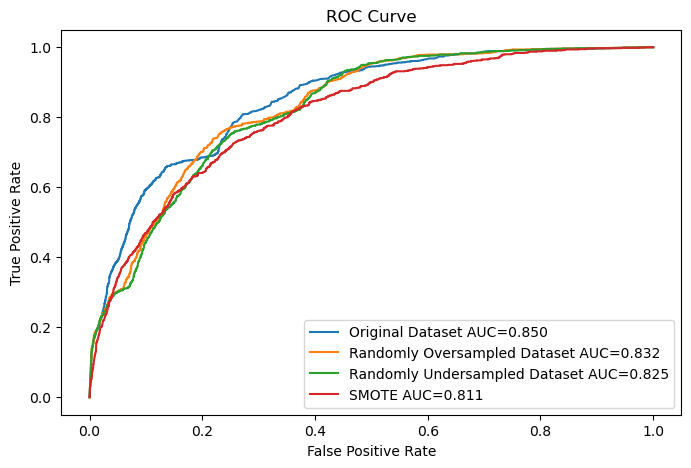

In [61]:
from sklearn.metrics import roc_curve, roc_auc_score

# Helper function for plotting ROC
def plot_roc(ax, est, X_train, y_train, X_test, y_test, title):
    y_test_pred = est.predict_proba(X_test)[:,1]
    fpr, tpr, thresh = roc_curve(y_test, y_test_pred, pos_label='yes')
    auc = roc_auc_score(y_test, y_test_pred)
    ax.plot(fpr,tpr,label=f"{title} AUC={auc:.3f}")

    ax.set_title('ROC Curve')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc=0)


fig,ax = plt.subplots(1,1,figsize=(8,5))
plot_roc(ax, rf, X_train, y_train, X_test, y_test, 'Original Dataset')
plot_roc(ax, rf_ros, X_train_ros, y_train_ros, X_test, y_test, 'Randomly Oversampled Dataset')
plot_roc(ax, rf_rus, X_train_rus, y_train_rus, X_test, y_test, 'Randomly Undersampled Dataset')
plot_roc(ax, rf_smote, X_train_smote, y_train_smote, X_test, y_test, 'SMOTE')

If we take the predictions from the original naive model, we can find the optimal threshold or around 0.1

In [62]:
y_test_pred = rf.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred[:,1], pos_label='yes')

threshold_rf = thresholds[np.argmax(tpr - fpr)]
print(f"Threshold for yes/no: {threshold_rf:.3f}")

Threshold for yes/no: 0.107


## Pipelines

As you might have guessed, machine learning can take quite a number of steps before you even get to training a model. Pipelines are functions that allow you to chain these steps together into an automated workflow, where data is input at one end, transformed and passed to an algorithm for training. This can help in a number of ways:

- Improve reproducibility
- Consistent processing of data (e.g. for test sets or new data for prediction)
- Allows tuning / optimization of multiple steps
- Facilitates deployment

We'll reload the breast cancer dataset here and build a simple pipeline as a demonstration

In [63]:
df = pd.read_csv('datafiles/breast_cancer_data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [64]:
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

First we'll illustrate the approach we have used so far. We are going to run a minmax transformation, then a PCA to select the first two new features, and finally pass this to a random forest. Note the need for intermediate datasets, and that if we reproduce this, we need to remember each individual step

In [65]:
# perform scaling
mms = MinMaxScaler()
X_train = mms.fit_transform(X_train)
X_test = mms.transform(X_test)

# perform pca
pca = PCA(n_components=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# train model
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

# generate predictions
y_test_pred = rfc.predict(X_test)

In [66]:
get_accuracy(y_test, y_test_pred)

Accuracy: 0.9580
Balanced accuracy: 0.9554


### Pipeline

Now let's see the same thing as a pipeline. We'll remake the feature and target datasets as these were transformed before

In [67]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Now we'll create the pipeline. Note that this is just a sequence of steps where we specify the scikit-learn functions

In [68]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[('scaler', MinMaxScaler()),
                   ('pca', PCA(n_components=2)),
                   ('model', RandomForestClassifier(random_state=42))])

In [69]:
from sklearn import set_config

set_config(display="diagram")
pipeline  # click on the diagram below to see the details of each step

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'


To now fit the model, we use the `fit` function on the *pipeline*. As this runs, it does all the steps of the pipeline, passing to the model at the end. We then use the pipeline to evaluate with `predict`. This pushes the test set through the same transformations, before using the random forest to predict. Note that we get the same accuracy, as all the steps are the same. The gain here is in the neatness of the code - one single fit and predict step. 

In [70]:
pipeline.fit(X_train, y_train)
y_test_pred = pipeline.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.9580
Balanced accuracy: 0.9554


### Pipeline tuning

Pipelines allow greater flexibility in tuning, as we can now tune not only the model, but any of the hyperparameters used in transforming the data. Let's look at the steps in the pipeline so far:

In [71]:
pipeline.steps

[('scaler', MinMaxScaler()),
 ('pca', PCA(n_components=2)),
 ('model', RandomForestClassifier(random_state=42))]

Let's try to tune two hyperparameters. First the number of principal components to retain (this is `n_components` in `PCA`). The second will be the number of trees in the random forest (`n_estimators`). Note that each hyperparameter is refered to by a combination of the label (e.g.`model` for the random forest) and the hyperparameter (`n_estimators`) separated by two underscores. As this is a demonstration, we'll just use two values for each. 

In [72]:
pipeline = Pipeline(steps=[('scaler', MinMaxScaler()),
                   ('pca', PCA()),
                   ('model', RandomForestClassifier(random_state=42))])

param_grid = {
    'pca__n_components':[2, 5],
    'model__n_estimators': [100, 1000]
}

In [73]:
from sklearn.model_selection import GridSearchCV

gs = GridSearchCV(pipeline,
                  param_grid=param_grid,
                  cv=3,
                  scoring='f1_micro',
                  n_jobs=-1)
gs.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__n_estimators': [100, 1000], 'pca__n_components': [2, 5]}"
,scoring,'f1_micro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,feature_range,"(0, ...)"


In [74]:
model = gs.best_estimator_
y_test_pred = model.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.9580
Balanced accuracy: 0.9554


In this case, there is no improvement in the model (which was already pretty good), but more extensive tuning might get soem improvement.